## Import Libraries

In [11]:
import sys
from pathlib import Path

_src = str(Path('../../src').resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from utils.matplotlib_config import register_matplotlib_setconfig
from config import get_base_dir, set_base_dir, DEFAULT_HALO_MASS_BINS
from analysis.mass_functions import (
    hmf_given_redshift_and_subvolume,
    compute_theoretical_hmfs
)
from analysis import hmfs_given_redshifts_and_subvolume

# Set the correct base directory
set_base_dir('/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = Path(get_base_dir())
register_matplotlib_setconfig(mpl)
mpl.setconfig()

## For a given redshift and sub volume, plot the HMF

In [12]:
halo_mass_lower_limit = 1e11

example_snapshot = 'iz271'
example_ivol = 40

hmf_result = hmf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if hmf_result is not None:
    z = hmf_result.get('z')
    z_str = f"{z:.3f}" if z is not None else "N/A"
    print(f"Loaded HMF for {hmf_result['iz']} (z={z_str}), ivol={hmf_result['ivol']}")
else:
    print(f"Failed to load HMF for {example_snapshot}, ivol={example_ivol}")

Loaded HMF for iz271 (z=N/A), ivol=40


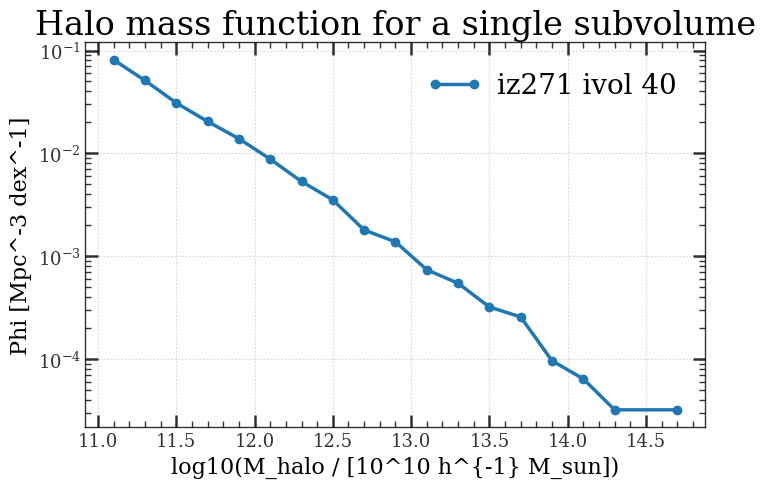

In [13]:
if hmf_result is not None:
    centers = hmf_result['centers']
    phi = hmf_result['phi']
    valid = np.isfinite(phi) & (phi > 0)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', label=f"{hmf_result['iz']} ivol {hmf_result['ivol']}")
    ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title("Halo mass function for a single subvolume")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("Cannot plot: hmf_result is None")

## For a given redshift and subvolume, compare to theoretical HMFs

In [14]:
example_snapshot = 'iz207'
example_ivol = 80
halo_mass_lower_limit = None

hmf_data = hmf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
)

if hmf_data is not None:
    theory_bins = DEFAULT_HALO_MASS_BINS

    theory_models = compute_theoretical_hmfs(
            z=hmf_data['z'],
            bins=theory_bins,
            use_mvir=True,
            include_ps_plus=True,
    )
    z = hmf_data['z']
    z_str = f"{z:.3f}" if z is not None else "N/A"
    print(f"Loaded HMF for {hmf_data['iz']} (z={z_str}), ivol={hmf_data['ivol']};", 
          f"computed {len(theory_models)} theory curves.")
else:
    print(f"Failed to load HMF for {example_snapshot}, ivol={example_ivol}")
    theory_models = {}

Loaded HMF for iz207 (z=N/A), ivol=80; computed 4 theory curves.


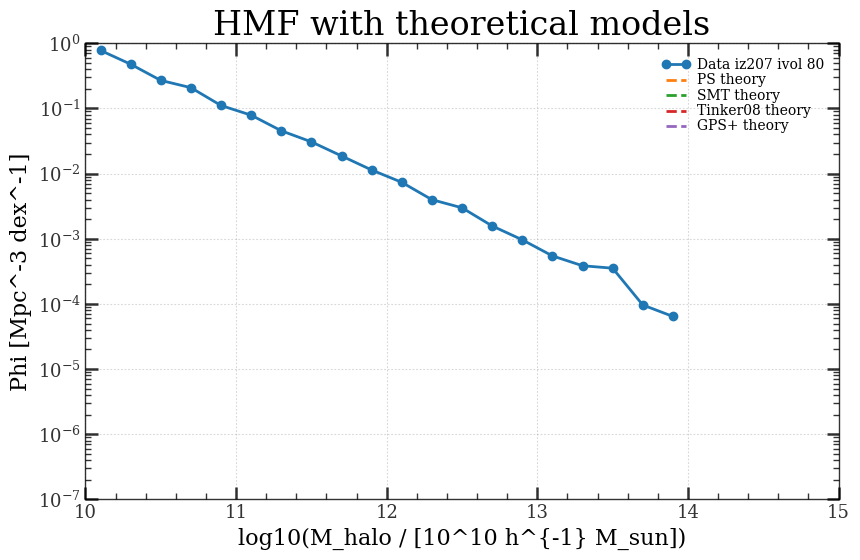

In [15]:
if hmf_data is not None and theory_models:
    centers = hmf_data['centers']
    phi = hmf_data['phi']
    valid = np.isfinite(phi) & (phi > 0)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', linewidth=2, markersize=6, label=f"Data {hmf_data['iz']} ivol {hmf_data['ivol']}")

    # Plot theory models - they're already interpolated to the right bins
    for name, model_phi in theory_models.items():
        # Filter out invalid values
        valid_theory = np.isfinite(model_phi) & (model_phi > 0)
        ax.plot(centers[valid_theory], model_phi[valid_theory], '--', linewidth=2, label=f"{name} theory")

    ax.set_xlim(10, 15)
    ax.set_ylim(1e-7, 1e0)
    ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title("HMF with theoretical models")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: hmf_data is None or theory_models is empty")

## HMFs for different redshifts

In [16]:
halo_mass_lower_limit = 1e11

example_ivol = 40
iz_nums = [155, 175, 207]

multi_hmf_result = hmfs_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    base_dir=base_dir,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if multi_hmf_result is not None:
    hmf_df, results_by_z = multi_hmf_result
    print(f"Loaded {len(results_by_z)} snapshots for ivol={example_ivol}")
else:
    print(f"Failed to load HMFs for ivol={example_ivol}")
    results_by_z = []

Loaded 2 snapshots for ivol=40


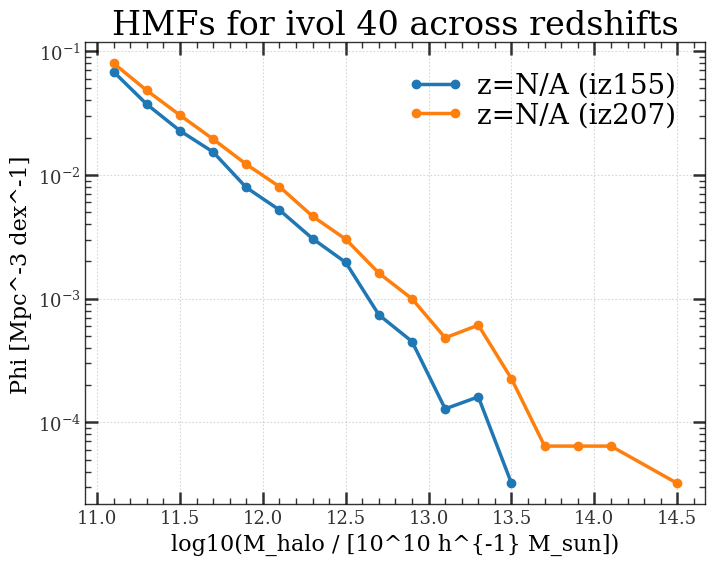

In [17]:
if results_by_z:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_yscale('log')
    for res in results_by_z:
        centers = res['centers']
        phi = res['phi']
        valid = np.isfinite(phi) & (phi > 0)
        z = res.get('z')
        z_str = f"{z:.2f}" if z is not None else "N/A"
        ax.plot(centers[valid], phi[valid], 'o-', label=f"z={z_str} ({res['iz']})")
    ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title(f"HMFs for ivol {example_ivol} across redshifts")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("Cannot plot: results_by_z is empty")

## For a given sub volume average over given redshifts

In [22]:
from analysis import avg_hmf_given_redshifts_and_subvolume

example_ivol = 0  # choose a subvolume
iz_nums = [155, 175, 207]  # snapshots that exist in base_dir

avg_hmf_result = avg_hmf_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if avg_hmf_result is not None:
    n_used = avg_hmf_result.get('n_used')
    n_requested = avg_hmf_result.get('n_requested')
    z_list = avg_hmf_result.get('z_list', [])
    # Filter out None values from z_list
    z_list_valid = [z for z in z_list if z is not None]
    z_min = f"{min(z_list_valid):.2f}" if z_list_valid else "N/A"
    z_max = f"{max(z_list_valid):.2f}" if z_list_valid else "N/A"
    print(
        f"Successfully used {n_used}/{n_requested} snapshots",
        f"ivol={avg_hmf_result['ivol']}",
        f"z range: {z_min}-{z_max}",
        sep='; '
    )
else:
    print(f"Failed to compute average HMF")
    avg_hmf_result = {}

Successfully used 2/3 snapshots; ivol=0; z range: N/A-N/A


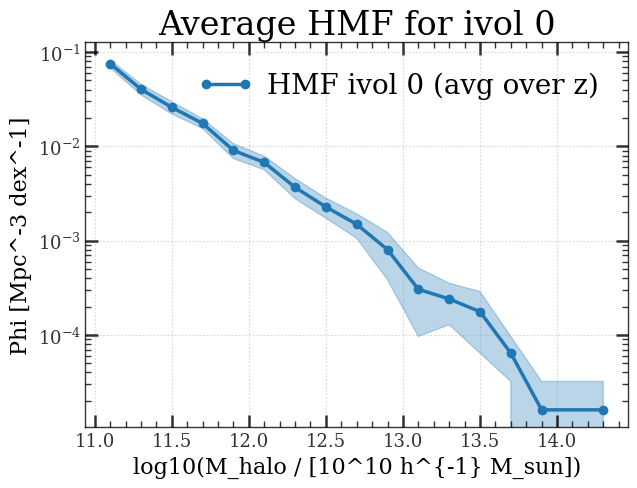

In [23]:
if avg_hmf_result and 'centers' in avg_hmf_result:
    centers = avg_hmf_result['centers']
    phi = avg_hmf_result['phi']
    phi_std = avg_hmf_result['phi_std']
    valid = np.isfinite(phi) & (phi > 0)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', label=f"HMF ivol {avg_hmf_result['ivol']} (avg over z)", color='C0')
    ax.fill_between(centers[valid], (phi - phi_std)[valid], (phi + phi_std)[valid], alpha=0.3, color='C0')
    ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
    ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
    ax.set_title(f"Average HMF for ivol {avg_hmf_result['ivol']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("Cannot plot: avg_hmf_result is empty or missing required data")